In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras.optimizers import Adamax
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, CSVLogger
from tensorflow.keras.regularizers import l2



In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf

# Directories
train_dir = '/content/drive/MyDrive/trainig_lungs'
test_dir = '/content/drive/MyDrive/testing_lungs'

# ImageDataGenerator with augmentation
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    shear_range=0.05,
    zoom_range=0.05,
    horizontal_flip=False,          # CT/PET often shouldn't be flipped
    fill_mode='nearest',
    brightness_range=[0.8, 1.2],
    preprocessing_function=lambda x: tf.image.random_contrast(x, lower=0.8, upper=1.2)
)

test_datagen = ImageDataGenerator(rescale=1.0 / 255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(512, 512),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32,
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(512, 512),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32,
    shuffle=False
)



Found 4274 images belonging to 5 classes.
Found 923 images belonging to 5 classes.


In [ ]:
import os
import pandas as pd

def count_files_in_subdirs(directory, set_name):
    counts = {}

    for item in os.listdir(directory):
        item_path = os.path.join(directory, item)

        if os.path.isdir(item_path):

            counts[item] = len(os.listdir(item_path))

    df = pd.DataFrame(counts, index=[set_name])
    return df


# Count the files in the subdirectories of the training directory and print the result.
train_count = count_files_in_subdirs(train_dir, 'train')
print(train_count)

# Count the files in the subdirectories of the testing directory and print the result.
test_count = count_files_in_subdirs(test_dir, 'test')
print(test_count)


       A001  B001  E001  G001  .ipynb_checkpoints
train  1089  1061  1110  1014                   0
      A001  B001  E001  G001  .ipynb_checkpoints
test   236   228   238   221                   0


<Axes: >

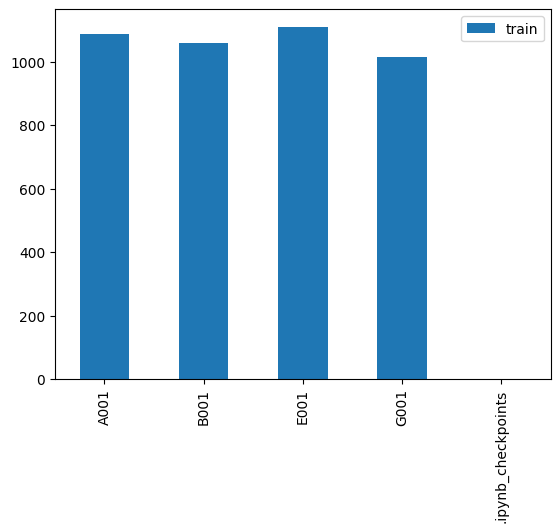

In [ ]:
train_count.transpose().plot(kind='bar')

<Axes: >

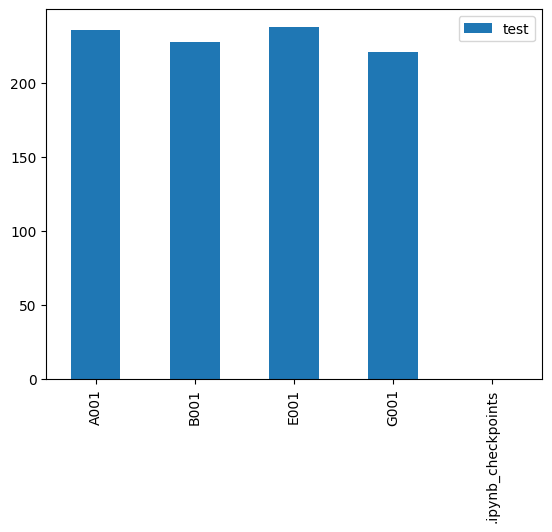

In [ ]:
test_count.transpose().plot(kind='bar')

In [ ]:
from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D, GlobalAveragePooling1D, Layer, MultiHeadAttention, LayerNormalization, Reshape
from tensorflow.keras.optimizers import Adamax
from tensorflow.keras.regularizers import l2
import tensorflow as tf
from tensorflow.keras.metrics import AUC
from keras.metrics import Precision, Recall
# Learning Rate Scheduler: Cosine Annealing
from tensorflow.keras.optimizers.schedules import CosineDecayRestarts
from tensorflow.keras.optimizers import Adam

# Define Vision Transformer Attention Block
class ViTAttention(Layer):
    def __init__(self, num_heads=8, embed_dim=128, **kwargs):
        super(ViTAttention, self).__init__(**kwargs)
        self.num_heads = num_heads
        self.embed_dim = embed_dim
        self.att = MultiHeadAttention(num_heads=self.num_heads, key_dim=self.embed_dim)
        self.layer_norm = LayerNormalization()

    def build(self, input_shape):
        super(ViTAttention, self).build(input_shape)

    def call(self, inputs, training=False):
        seq_len = inputs.shape[1]  # Height or width of the image
        inputs_reshaped = tf.reshape(inputs, (-1, seq_len, self.embed_dim))  # Reshape the inputs

        # Apply multi-head attention
        att_output = self.att(inputs_reshaped, inputs_reshaped)

        # Add residual connection and apply layer normalization
        output = self.layer_norm(inputs_reshaped + att_output)

        return output

# Model Creation
input_shape = (512, 512, 3)
base_model = ResNet50V2(include_top=False, weights='imagenet', input_shape=input_shape)

# Freeze base model initially
for layer in base_model.layers:
    layer.trainable = False

# Add custom layers including ViTAttention
inputs = Input(shape=input_shape)
x = base_model(inputs, training=False)
x = BatchNormalization()(x)
x = GlobalAveragePooling2D()(x)

# Reshape for ViTAttention
x = Reshape((-1, 128))(x)  # Adjust embed_dim if necessary

# Apply Vision Transformer Attention Block
x = ViTAttention(num_heads=8, embed_dim=128)(x)

# Pooling after attention to reduce dimensions
x = GlobalAveragePooling1D()(x)

# Fully Connected Layers for Classification
x = Dense(256, activation='relu', kernel_regularizer=l2(0.001))(x)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu', kernel_regularizer=l2(0.001))(x)
x = Dropout(0.3)(x)
outputs = Dense(4, activation='softmax')(x)

# Define the model
model = Model(inputs=inputs, outputs=outputs)



# Calculate steps
steps_per_epoch = train_generator.samples // train_generator.batch_size
validation_steps = test_generator.samples // test_generator.batch_size



# Parameters for Cosine Decay Restarts
initial_lr = 0.001
first_decay_steps = steps_per_epoch * 20  # Number of steps for the first restart
t_mul = 2  # Increase in the number of steps after each restart
m_mul = 1.0  # Multiplier for the minimum learning rate
alpha = 0.0  # Minimum learning rate as a fraction of the initial learning rate

# Cosine Decay Restarts scheduler
lr_schedule = CosineDecayRestarts(
    initial_learning_rate=initial_lr,
    first_decay_steps=first_decay_steps,
    t_mul=t_mul,
    m_mul=m_mul,
    alpha=alpha
)

# Optimizer with Cosine Decay Restarts
optimizer = Adamax(learning_rate=lr_schedule)

# Compile model with the updated optimizer


model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy', AUC(name='auc'), Precision(), Recall()]
)

# Print model summary
model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)           │ (None, 512, 512, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ resnet50v2 (Functional)              │ (None, 16, 16, 2048)        │      23,564,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 16, 16, 2048)        │           8,192 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 2048)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ reshape_1 (Reshape)                  │ (None, 16, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ vi_t_attention_1 (ViTAttention)      │ (None, 16, 128)             │         527,744 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling1d_1           │ (None, 128)                 │               0 │
│ (GlobalAveragePooling1D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 256)                 │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 4)                   │             516 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 24,167,172 (92.19 MB)

 Trainable params: 598,276 (2.28 MB)

 Non-trainable params: 23,568,896 (89.91 MB)

In [ ]:
import os
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau,CSVLogger



# File path for the model checkpoint
cnn_path = '/content/drive/MyDrive'
name = 'ResNet50_Transfer_Learning.keras'
chk_path = os.path.join(cnn_path, name)

# Callback to save the model checkpoint
checkpoint = ModelCheckpoint(filepath=chk_path,
                             save_best_only=True,
                             verbose=1,
                             mode='min',
                             monitor='val_loss')

# Callback for early stopping
earlystop = EarlyStopping(monitor='val_loss',
                          min_delta=0,
                          patience=3,
                          verbose=1,
                          restore_best_weights=True)

# Callback to reduce learning rate
reduce_lr = ReduceLROnPlateau(monitor='val_loss',
                              factor=0.2,
                              patience=3,
                              verbose=1,
                              min_delta=0.0001)

# Callback to log training data to a CSV file
csv_logger = CSVLogger(os.path.join(cnn_path,'training.log'))

# Aggregating all callbacks into a list
callbacks = [checkpoint, earlystop]  # Adjusted as per your use-case

train_steps_per_epoch = train_generator.samples // train_generator.batch_size + 1
# validation_steps_epoch = validation_generator.samples // validation_generator.batch_size + 1
test_steps_epoch = test_generator.samples // test_generator.batch_size + 1

In [ ]:

import math

from tensorflow.keras.callbacks import ReduceLROnPlateau, ModelCheckpoint, EarlyStopping





train_history = model.fit(
    train_generator,
    steps_per_epoch=30,
    epochs=20,
    validation_data=test_generator,
    validation_steps=10,
    callbacks=callbacks
)




Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.4582 - auc: 0.7207 - loss: 1.5712 - precision_2: 0.6451 - recall_2: 0.0628
Epoch 1: val_loss improved from inf to 1.17743, saving model to /content/drive/MyDrive/ResNet50_Transfer_Learning.keras
30/30 ━━━━━━━━━━━━━━━━━━━━ 152s 4s/step - accuracy: 0.4613 - auc: 0.7237 - loss: 1.5667 - precision_2: 0.6502 - recall_2: 0.0666 - val_accuracy: 0.5906 - val_auc: 0.8683 - val_loss: 1.1774 - val_precision_2: 0.7160 - val_recall_2: 0.3625
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6938 - auc: 0.9058 - loss: 1.1013 - precision_2: 0.8199 - recall_2: 0.5784
Epoch 2: val_loss improved from 1.17743 to 0.98816, saving model to /content/drive/MyDrive/ResNet50_Transfer_Learning.keras
30/30 ━━━━━━━━━━━━━━━━━━━━ 98s 3s/step - accuracy: 0.6947 - auc: 0.9062 - loss: 1.0996 - precision_2: 0.8203 - recall_2: 0.5796 - val_accuracy: 0.7844 - val_auc: 0.9455 - val_loss: 0.9882 - val_precision_2: 0.9234 - val_recall_2: 0.6406
Epoch

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 5: val_loss did not improve from 0.62081
30/30 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.8414 - auc: 0.9681 - loss: 0.7491 - precision_2: 0.8656 - recall_2: 0.8129 - val_accuracy: 0.8625 - val_auc: 0.9752 - val_loss: 0.7101 - val_precision_2: 0.8818 - val_recall_2: 0.8156
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8810 - auc: 0.9835 - loss: 0.6361 - precision_2: 0.9101 - recall_2: 0.8534
Epoch 6: val_loss did not improve from 0.62081
30/30 ━━━━━━━━━━━━━━━━━━━━ 142s 3s/step - accuracy: 0.8813 - auc: 0.9835 - loss: 0.6360 - precision_2: 0.9103 - recall_2: 0.8537 - val_accuracy: 0.8188 - val_auc: 0.9679 - val_loss: 0.7523 - val_precision_2: 0.8388 - val_recall_2: 0.7969
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 3.


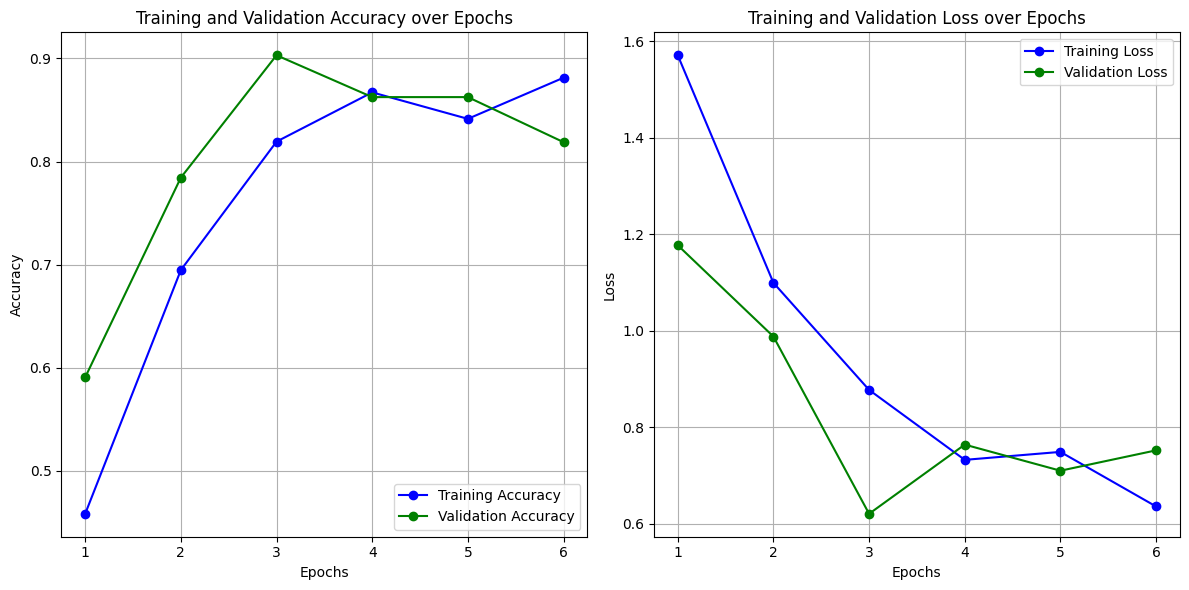

In [ ]:
import matplotlib.pyplot as plt


# Extract accuracy values from history
history = train_history.history
train_accuracy = history['accuracy']
val_accuracy = history['val_accuracy']

# Extract loss values from history
train_loss = history['loss']
val_loss = history['val_loss']

# Define epochs
epochs = range(1, len(train_accuracy) + 1)

# Plotting Accuracy and Loss
plt.figure(figsize=(12, 6))

# Plotting Training and Validation Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs, train_accuracy, 'bo-', label='Training Accuracy')
plt.plot(epochs, val_accuracy, 'go-', label='Validation Accuracy')
plt.title('Training and Validation Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plotting Training and Validation Loss
plt.subplot(1, 2, 2)
plt.plot(epochs, train_loss, 'bo-', label='Training Loss')
plt.plot(epochs, val_loss, 'go-', label='Validation Loss')
plt.title('Training and Validation Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Show the plots
plt.tight_layout()
plt.show()


In [ ]:
#Fine tune
# After initial training:
for layer in base_model.layers[-30:]:  # unfreeze last few blocks
    layer.trainable = True


# Optimizer with Cosine Decay Restarts
optimizer = Adamax(learning_rate=lr_schedule)
model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy', AUC(name='auc'), Precision(), Recall()]
)

steps_per_epoch = train_generator.samples // train_generator.batch_size
validation_steps = test_generator.samples // test_generator.batch_size


train_history = model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch,
    epochs=10,
    validation_data=test_generator,
    validation_steps=validation_steps,
    callbacks=callbacks
)


Epoch 1/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8886 - auc: 0.9732 - loss: 0.6676 - precision_4: 0.9018 - recall_4: 0.8839
Epoch 1: val_loss improved from 0.62081 to 0.59044, saving model to /content/drive/MyDrive/ResNet50_Transfer_Learning.keras
133/133 ━━━━━━━━━━━━━━━━━━━━ 438s 3s/step - accuracy: 0.8891 - auc: 0.9733 - loss: 0.6661 - precision_4: 0.9022 - recall_4: 0.8844 - val_accuracy: 0.9051 - val_auc: 0.9835 - val_loss: 0.5904 - val_precision_4: 0.9060 - val_recall_4: 0.9040
Epoch 2/10
  1/133 ━━━━━━━━━━━━━━━━━━━━ 1:01 463ms/step - accuracy: 1.0000 - auc: 1.0000 - loss: 0.3073 - precision_4: 1.0000 - recall_4: 1.0000
Epoch 2: val_loss improved from 0.59044 to 0.57405, saving model to /content/drive/MyDrive/ResNet50_Transfer_Learning.keras
133/133 ━━━━━━━━━━━━━━━━━━━━ 21s 156ms/step - accuracy: 1.0000 - auc: 1.0000 - loss: 0.3073 - precision_4: 1.0000 - recall_4: 1.0000 - val_accuracy: 0.9141 - val_auc: 0.9842 - val_loss: 0.5740 - val_precision_4: 0.9160 - val_re

29/29 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step
Classification Report:

              precision    recall  f1-score   support

      A001-M       0.96      1.00      0.98       236
      B000-M       0.99      1.00      0.99       228
      E001-M       0.98      0.96      0.97       238
      G025-M       1.00      0.95      0.97       221

    accuracy                           0.98       923
   macro avg       0.98      0.98      0.98       923
weighted avg       0.98      0.98      0.98       923



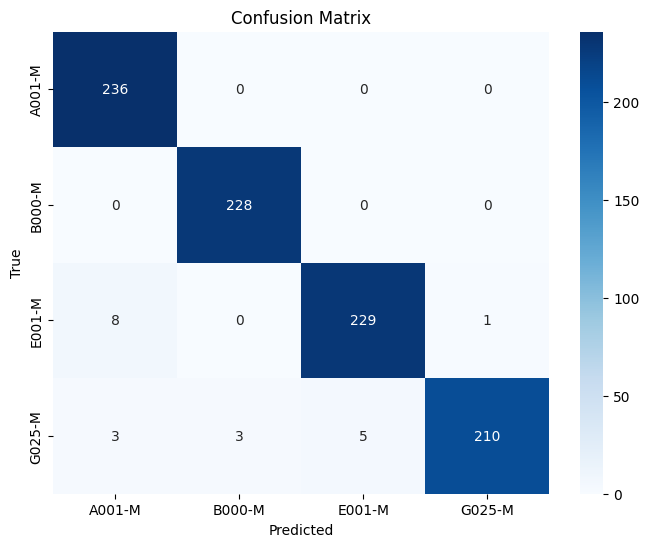

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Predict
y_pred_probs = model.predict(test_generator, steps=test_steps_epoch, verbose=1)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true = test_generator.classes

# Step 2: Labels
class_labels = list(test_generator.class_indices.keys())

# Step 3: Classification Report
print("Classification Report:\n")
print(classification_report(y_true, y_pred_classes, target_names=class_labels))

# Step 4: Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Step 5: Plot Confusion Matrix
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
from tensorflow.keras.layers import Layer,MultiHeadAttention,LayerNormalization
import tensorflow as tf



# Define Vision Transformer Attention Block
class ViTAttention(Layer):
    def __init__(self, num_heads=8, embed_dim=128, **kwargs):
        super(ViTAttention, self).__init__(**kwargs)
        self.num_heads = num_heads
        self.embed_dim = embed_dim
        self.att = MultiHeadAttention(num_heads=self.num_heads, key_dim=self.embed_dim)
        self.layer_norm = LayerNormalization()

    def build(self, input_shape):
        super(ViTAttention, self).build(input_shape)

    def call(self, inputs, training=False):
        seq_len = inputs.shape[1]  # Height or width of the image
        inputs_reshaped = tf.reshape(inputs, (-1, seq_len, self.embed_dim))  # Reshape the inputs

        # Apply multi-head attention
        att_output = self.att(inputs_reshaped, inputs_reshaped)

        # Add residual connection and apply layer normalization
        output = self.layer_norm(inputs_reshaped + att_output)

        return output
# Now you can load the model
from keras.models import load_model
model = load_model('/content/drive/MyDrive/ResNet50_ViT_Hybrid.keras', custom_objects={'ViTAttention': ViTAttention})

In [ ]:
import pydicom
from PIL import Image
def convert_dcm_to_png(file_path):
    # Check if the file is a DICOM file by checking the 'DICM' prefix
    try:
        if file_path.lower().endswith('.dcm'):
            # Try reading the DICOM file
            dicom_image = pydicom.dcmread(file_path, force=True)

            # Convert to PIL Image
            img = Image.fromarray(dicom_image.pixel_array)

            # Check the image mode and convert if necessary
            if img.mode == 'I;16':
                img = img.convert('L')  # Convert to 8-bit grayscale
            elif img.mode == 'I':
                img = img.convert('L')  # Convert to 8-bit grayscale
            elif img.mode == 'RGB':
                pass  # No conversion needed
            else:
                img = img.convert('RGB')  # Convert to RGB if needed

            # Create the new PNG file path (replacing .dcm with .png)
            png_path = file_path[:-4] + '.png'
            img.save(png_path)


            return png_path
        else:
            # Return the path as is if it's not a DICOM file
            return file_path

    except Exception as e:
        print(f"Error converting {file_path}: {e}")
        return None

def load_and_prep_image(file_path, img_height, img_width):
    img = image.load_img(file_path, target_size=(img_height, img_width))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, 0)  # Add batch dimension
    return img_array / 255.0  # Normalize to [0, 1]


class_names = ['A', 'B', 'E', 'G',]

In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np

# Path to the input image (DICOM or PNG)
test_image_path = "/content/1-13.dcm"  # Replace with the correct path

# Convert the DICOM to PNG if necessary (only if the file is DICOM)
converted_image_path = convert_dcm_to_png(test_image_path)

# If conversion was successful or the file was already PNG, predict using the model
if converted_image_path:
    img = load_and_prep_image(converted_image_path, 512, 512)

    # Assuming 'model' is already loaded
    predictions = model.predict(img)
    index = np.argmax(predictions)
    predicted_class = class_names[index]

    # Output predicted class and confidence score
    print(f'Predicted class: {predicted_class}, Confidence: {predictions[0][index]}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
Predicted class: A, Confidence: 0.9999021291732788


In [ ]:
# def load_and_prep_image(file_path, img_height, img_width):
#     img = image.load_img(file_path, target_size=(img_height, img_width))
#     img_array = image.img_to_array(img)
#     img_array = tf.expand_dims(img_array, 0)  # Create a batch
#     return img_array / 255.0
# #testing
# class_names = ['A', 'B', 'E', 'G',]

In [ ]:
# from tensorflow.keras.preprocessing import image
# import tensorflow as tf
# import numpy as np


# test_image_path = "/content/1-28.dcm"
# img = load_and_prep_image(test_image_path, 512, 512)

# predictions = model.predict(img)
# index=np.argmax(predictions)
# print(index)

# predicted_class = class_names[np.argmax(predictions)]
# print(f'Predicted class: {predicted_class, predictions[0][np.argmax(predictions)]}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
3
Predicted class: ('G', np.float32(0.9719426))


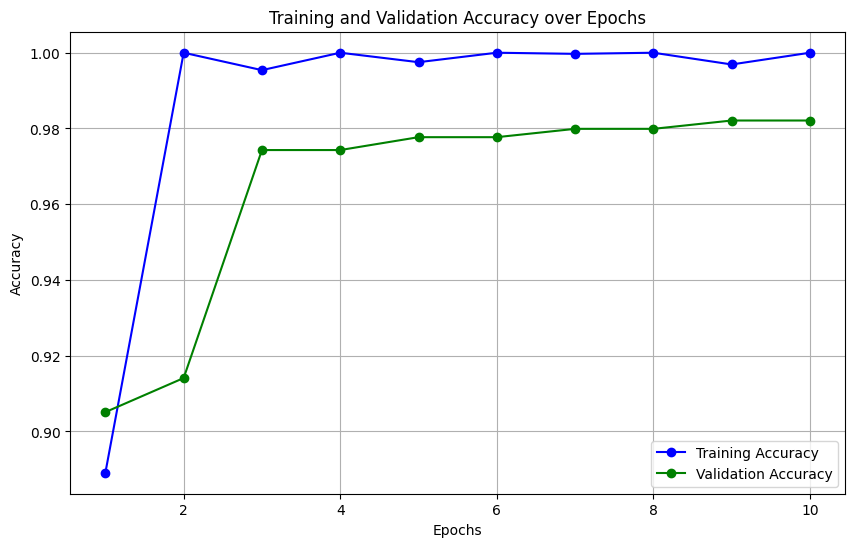

In [ ]:
import matplotlib.pyplot as plt

# Extract accuracy values from history
history = train_history.history
train_accuracy = history['accuracy']
val_accuracy = history['val_accuracy']

# Define epochs
epochs = range(1, len(train_accuracy) + 1)

# Plotting the graph
plt.figure(figsize=(10, 6))
plt.plot(epochs, train_accuracy, 'bo-', label='Training Accuracy')
plt.plot(epochs, val_accuracy, 'go-', label='Validation Accuracy')
plt.title('Training and Validation Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()


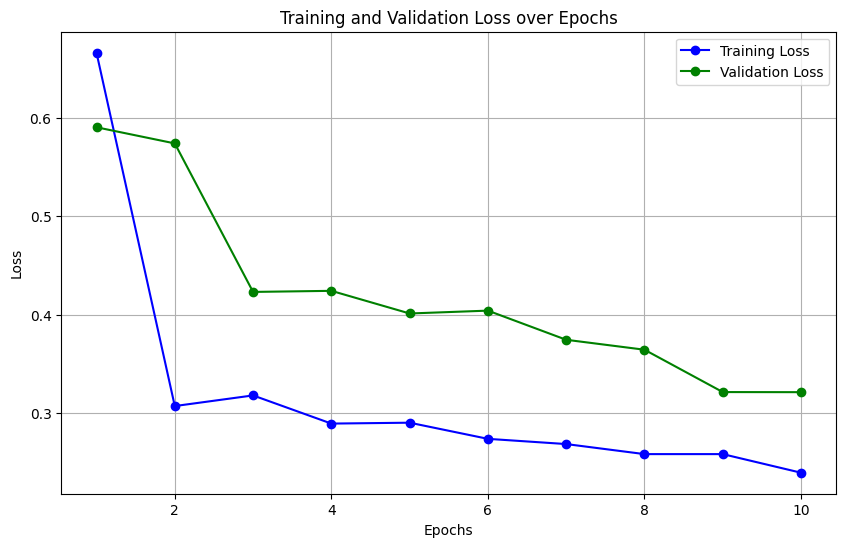

In [ ]:
import matplotlib.pyplot as plt

# Extract loss values from history
train_loss = history['loss']
val_loss = history['val_loss']

# Define epochs
epochs = range(1, len(train_loss) + 1)

# Plotting the graph
plt.figure(figsize=(10, 6))
plt.plot(epochs, train_loss, 'bo-', label='Training Loss')
plt.plot(epochs, val_loss, 'go-', label='Validation Loss')
plt.title('Training and Validation Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


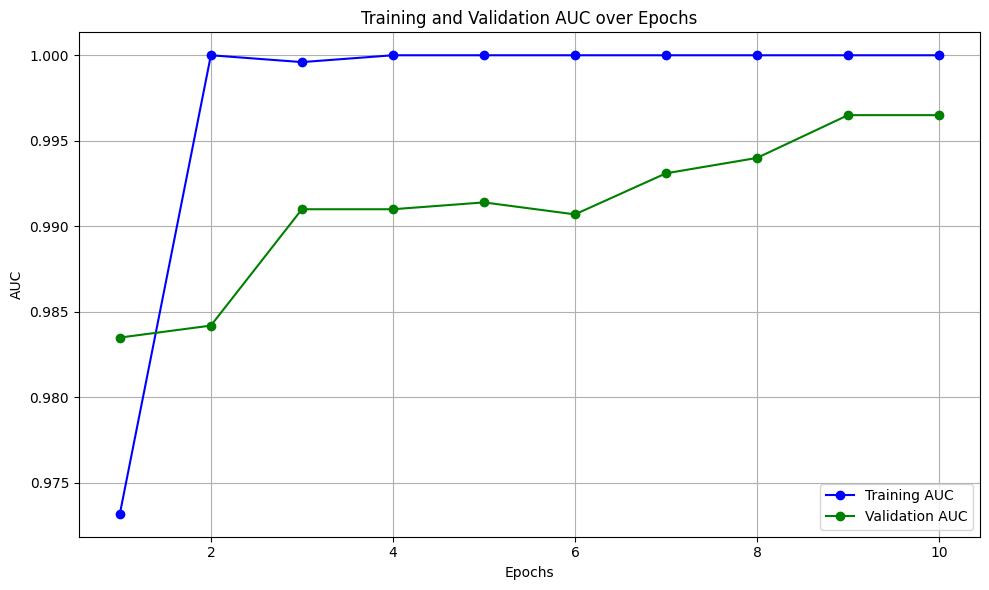

In [ ]:
import matplotlib.pyplot as plt

# AUC values from your logs

train_auc = history.history['auc']
val_auc = history.history['val_auc']

epochs = range(1, len(history.history['auc']) + 1)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(epochs, train_auc, 'bo-', label='Training AUC')
plt.plot(epochs, val_auc, 'go-', label='Validation AUC')
plt.title('Training and Validation AUC over Epochs')
plt.xlabel('Epochs')
plt.ylabel('AUC')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


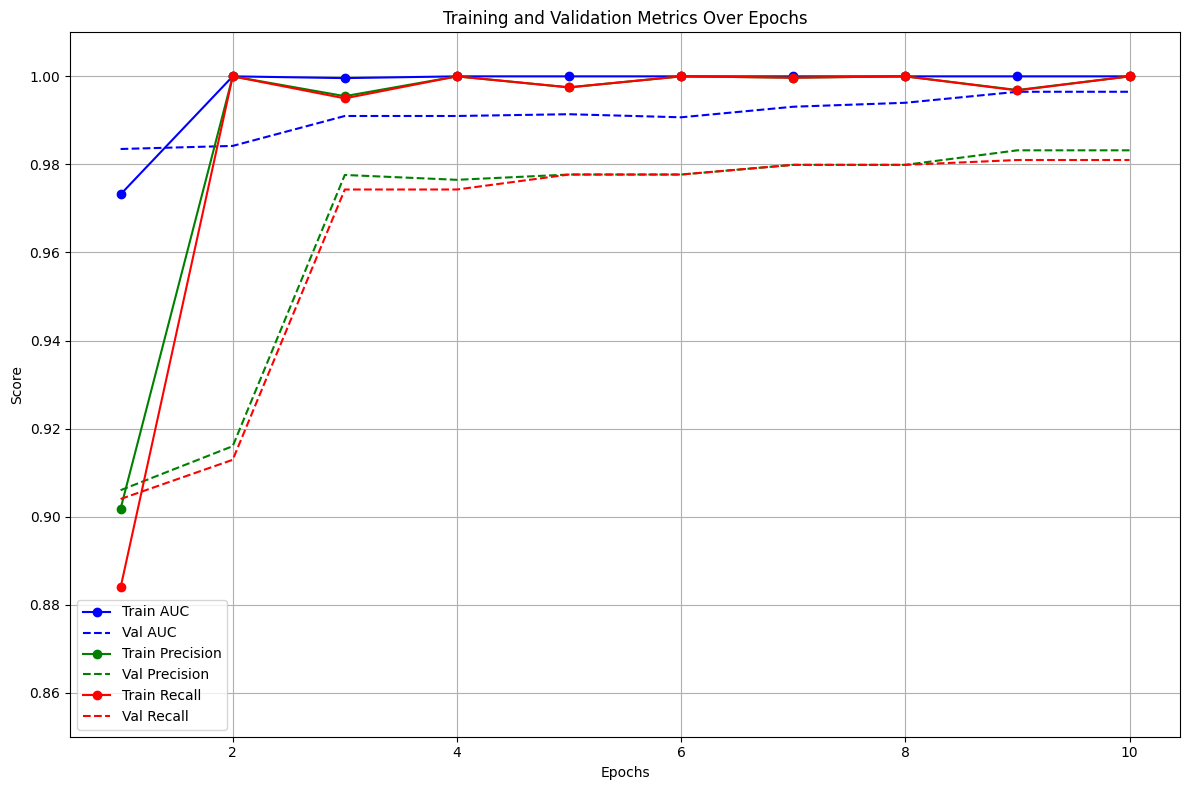

In [ ]:
# Precision and Recall values from your logs
train_precision = history.history['precision']
val_precision = history.history['val_precision']

train_recall = history.history['recall']
val_recall = history.history['val_recall']

epochs = range(1, len(history.history['val_precision']) + 1)


# Plotting all metrics
plt.figure(figsize=(12, 8))

# AUC
plt.plot(epochs, train_auc, 'bo-', label='Train AUC')
plt.plot(epochs, val_auc, 'b--', label='Val AUC')

# Precision
plt.plot(epochs, train_precision, 'go-', label='Train Precision')
plt.plot(epochs, val_precision, 'g--', label='Val Precision')

# Recall
plt.plot(epochs, train_recall, 'ro-', label='Train Recall')
plt.plot(epochs, val_recall, 'r--', label='Val Recall')

plt.title('Training and Validation Metrics Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Score')
plt.ylim(0.85, 1.01)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
!pip install lime


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 7.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=71d1e7334541e945b714d3889be98eab2bab26e3e84cc7f3494555185e4ee774
  Stored in directory: /root/.cache/pip/wheels/85/fa/a3/9c2d44c9f3cd77cf4e533b58900b2bf4487f2a17e8ec212a3d
Successfully built lime


##LIME

  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 349ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

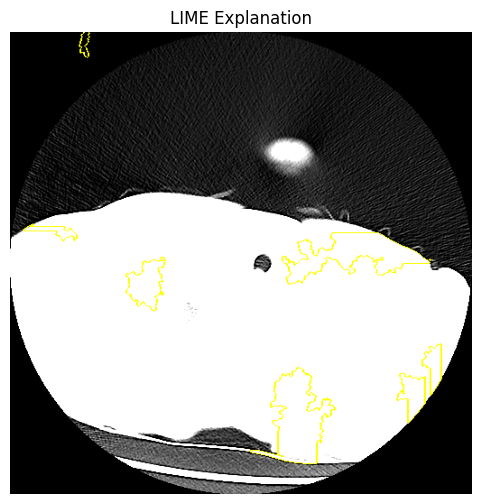

In [ ]:
# Import necessary libraries
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
from lime import lime_image

from skimage.segmentation import mark_boundaries
import tensorflow.keras.applications.resnet_v2

# Your existing function and code

# Function to predict from numpy image
def predict_lime(imgs):
    imgs = tf.image.resize(imgs, (512, 512))
    imgs = tf.keras.applications.resnet_v2.preprocess_input(imgs)
    return model.predict(imgs)

# Setup LIME Explainer
explainer = lime_image.LimeImageExplainer()

# Prepare the raw image for LIME
img_path = "/content/drive/MyDrive/testing_lungs/G001/1-03.png"

img_raw = image.load_img(img_path, target_size=(512, 512))
img_np = image.img_to_array(img_raw).astype('double') / 255.0

# Run LIME
explanation = explainer.explain_instance(
    image=img_np,
    classifier_fn=predict_lime,
    top_labels=1,
    hide_color=0,
    num_samples=1000
)

# Visualize LIME explanation
temp, mask = explanation.get_image_and_mask(
    label=explanation.top_labels[0],
    positive_only=True,
    hide_rest=False,
    num_features=10,
    min_weight=0.0
)

plt.figure(figsize=(6, 6))
plt.imshow(mark_boundaries(temp, mask))
plt.axis('off')
plt.title('LIME Explanation')
plt.show()


#AUGMENTATION TEST

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


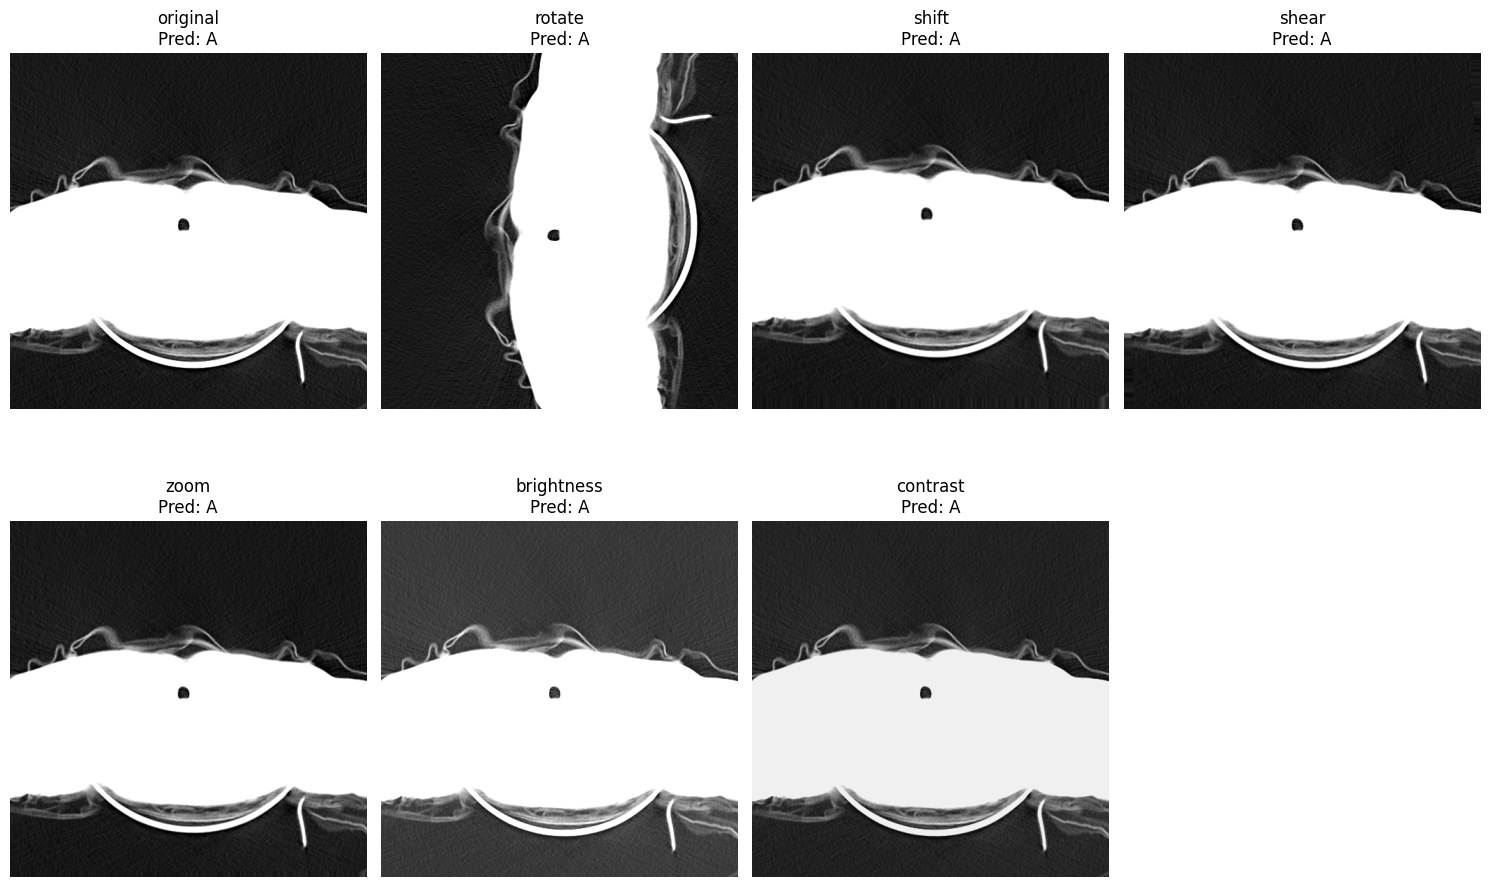

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import cv2

# ---------- 1. Load one test image ----------
img_path = '/content/drive/MyDrive/testing_lungs/A001/1-01.png'
original_img = cv2.imread(img_path)
original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
img_resized = cv2.resize(original_img, (512, 512)) / 255.0
img_tensor = tf.convert_to_tensor(img_resized, dtype=tf.float32)

# ---------- 2. Define augmentations ----------
def rotate(img): return tf.image.rot90(img, k=1)
def shift(img): return tf.convert_to_tensor(
    tf.keras.preprocessing.image.random_shift(img.numpy(), 0.05, 0.05,
                                              row_axis=0, col_axis=1, channel_axis=2, fill_mode='nearest'),
    dtype=tf.float32)
def shear(img): return tf.convert_to_tensor(
    tf.keras.preprocessing.image.random_shear(img.numpy(), 5,
                                              row_axis=0, col_axis=1, channel_axis=2, fill_mode='nearest'),
    dtype=tf.float32)
def zoom(img): return tf.convert_to_tensor(
    tf.keras.preprocessing.image.random_zoom(img.numpy(), (0.95, 1.05),
                                             row_axis=0, col_axis=1, channel_axis=2, fill_mode='nearest'),
    dtype=tf.float32)
def brightness(img): return tf.image.random_brightness(img, 0.2)
def contrast(img): return tf.image.random_contrast(img, 0.8, 1.2)

augmentations = {
    "original": img_tensor,
    "rotate": rotate(img_tensor),
    "shift": shift(img_tensor),
    "shear": shear(img_tensor),
    "zoom": zoom(img_tensor),
    "brightness": brightness(img_tensor),
    "contrast": contrast(img_tensor),
}

# ---------- 3. Predict each augmented image ----------
class_names = ['A', 'B', 'E', 'G']  # model ke training order ke according ho

plt.figure(figsize=(15, 10))

for idx, (aug_name, aug_img) in enumerate(augmentations.items()):
    aug_img_expanded = tf.expand_dims(aug_img, axis=0)
    prediction = model.predict(aug_img_expanded)
    predicted_class = np.argmax(prediction)

    predicted_Label=class_names[predicted_class]



    plt.subplot(2, 4, idx + 1)
    plt.imshow(np.clip(aug_img.numpy(), 0, 1))
    plt.axis('off')
    plt.title(f"{aug_name}\nPred: {predicted_Label}")

plt.tight_layout()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step


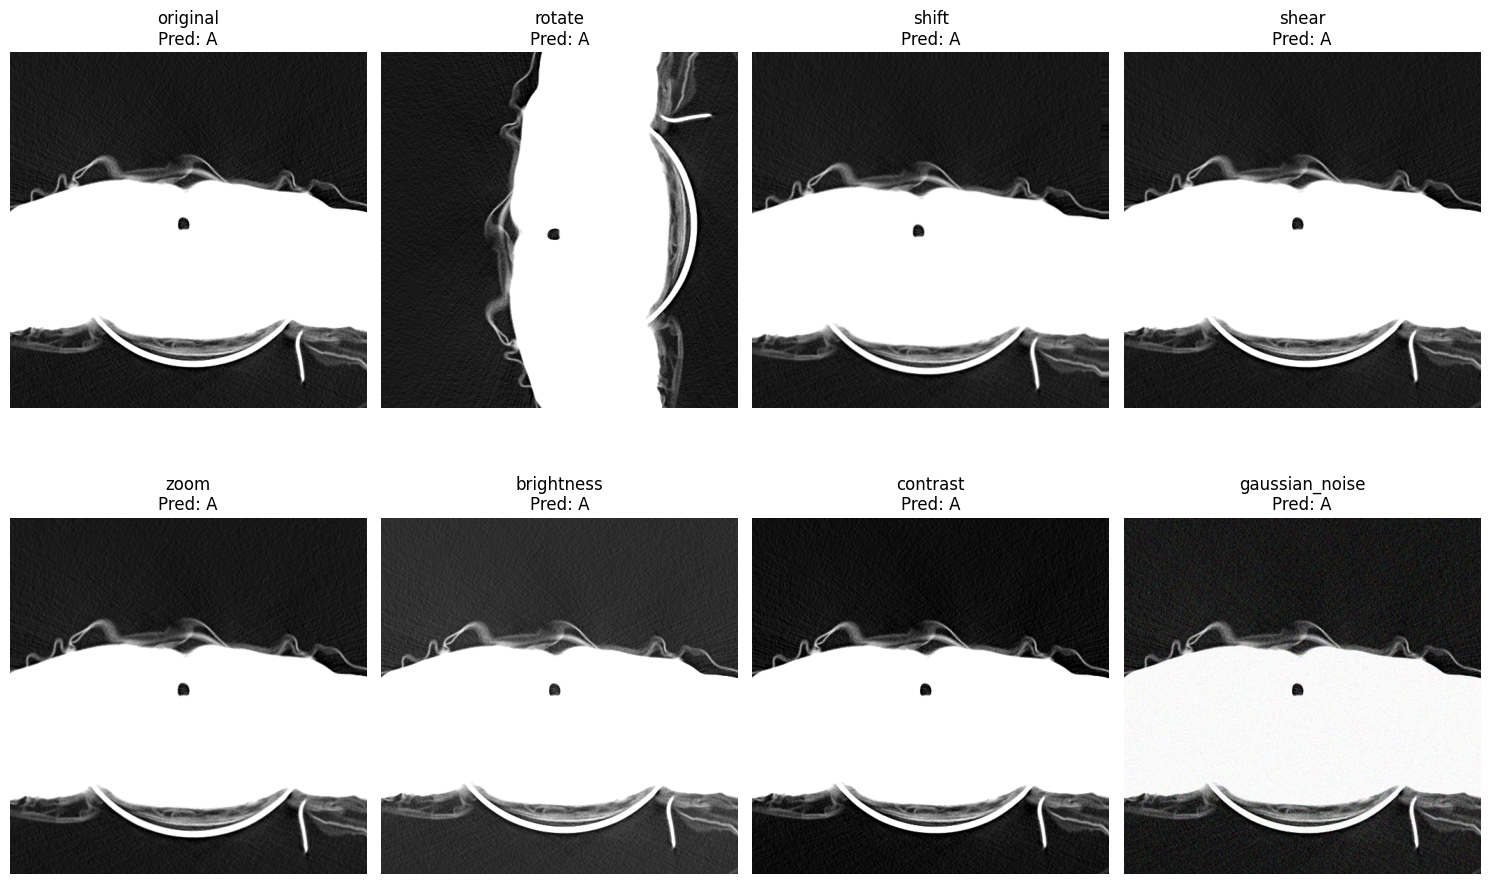

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import cv2

# ---------- 1. Load one test image ----------
img_path = '/content/drive/MyDrive/testing_lungs/A001/1-01.png'
original_img = cv2.imread(img_path)
original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
img_resized = cv2.resize(original_img, (512, 512)) / 255.0
img_tensor = tf.convert_to_tensor(img_resized, dtype=tf.float32)

# ---------- 2. Define augmentations ----------
def rotate(img): return tf.image.rot90(img, k=1)

def shift(img):
    return tf.convert_to_tensor(
        tf.keras.preprocessing.image.random_shift(img.numpy(), 0.05, 0.05,
                                                  row_axis=0, col_axis=1, channel_axis=2, fill_mode='nearest'),
        dtype=tf.float32)

def shear(img):
    return tf.convert_to_tensor(
        tf.keras.preprocessing.image.random_shear(img.numpy(), 5,
                                                  row_axis=0, col_axis=1, channel_axis=2, fill_mode='nearest'),
        dtype=tf.float32)

def zoom(img):
    return tf.convert_to_tensor(
        tf.keras.preprocessing.image.random_zoom(img.numpy(), (0.95, 1.05),
                                                 row_axis=0, col_axis=1, channel_axis=2, fill_mode='nearest'),
        dtype=tf.float32)

def brightness(img): return tf.image.random_brightness(img, 0.2)
def contrast(img): return tf.image.random_contrast(img, 0.8, 1.2)

def gaussian_noise(img):
    noise = tf.random.normal(shape=tf.shape(img), mean=0.0, stddev=0.05, dtype=tf.float32)
    return tf.clip_by_value(img + noise, 0.0, 1.0)

augmentations = {
    "original": img_tensor,
    "rotate": rotate(img_tensor),
    "shift": shift(img_tensor),
    "shear": shear(img_tensor),
    "zoom": zoom(img_tensor),
    "brightness": brightness(img_tensor),
    "contrast": contrast(img_tensor),
    "gaussian_noise": gaussian_noise(img_tensor),
}

# ---------- 3. Predict each augmented image ----------
class_names = ['A', 'B', 'E', 'G']

plt.figure(figsize=(15, 10))

for idx, (aug_name, aug_img) in enumerate(augmentations.items()):
    aug_img_expanded = tf.expand_dims(aug_img, axis=0)
    prediction = model.predict(aug_img_expanded)
    predicted_class = np.argmax(prediction)

    predicted_Label = class_names[predicted_class]

    plt.subplot(2, 4, idx + 1)
    plt.imshow(np.clip(aug_img.numpy(), 0, 1))
    plt.axis('off')
    plt.title(f"{aug_name}\nPred: {predicted_Label}")

plt.tight_layout()
plt.show()
